# Correlate Download Activity with additions and deletions

We do this for the cross-section of repos. 

In [1]:
import os
import sys
sys.path.append('../src')
import stats
import pandas as pd
import pypistats
import time
import matplotlib.pyplot as plt


In [2]:
projects = pd.read_csv('projects_list.csv', header=None)
projects.columns = ['name', 'repo', 'pypi_package_name']
projects

,name,repo,pypi_package_name
0,Dask,dask/dask,dask
1,HuggingFace,huggingface/transformers,transformers
2,IPython,ipython/ipython,ipython
3,Jax,jax-ml/jax,jax
4,JupyterScheduler,jupyter-server/jupyter-scheduler,jupyter-scheduler
5,Jupyter-AI,jupyterlab/jupyter-ai,jupyter-ai
6,JupyterLab,jupyterlab/jupyterlab,jupyterlab
7,KubeFlow,kubeflow/kubeflow,kubeflow
8,Kubernetes,kubernetes/kubernetes,kubernetes
9,Kueue,kubernetes-sigs/kueue,kueue


In [3]:
run_list = []
for i, row in projects.iterrows():
    x = row.to_dict()
    for k in x.keys():
        x[k] = x[k].strip()
    run_list.append(x)
run_list

[{'name': 'Dask', 'repo': 'dask/dask', 'pypi_package_name': 'dask'},
 {'name': 'HuggingFace',
  'repo': 'huggingface/transformers',
  'pypi_package_name': 'transformers'},
 {'name': 'IPython',
  'repo': 'ipython/ipython',
  'pypi_package_name': 'ipython'},
 {'name': 'Jax', 'repo': 'jax-ml/jax', 'pypi_package_name': 'jax'},
 {'name': 'JupyterScheduler',
  'repo': 'jupyter-server/jupyter-scheduler',
  'pypi_package_name': 'jupyter-scheduler'},
 {'name': 'Jupyter-AI',
  'repo': 'jupyterlab/jupyter-ai',
  'pypi_package_name': 'jupyter-ai'},
 {'name': 'JupyterLab',
  'repo': 'jupyterlab/jupyterlab',
  'pypi_package_name': 'jupyterlab'},
 {'name': 'KubeFlow',
  'repo': 'kubeflow/kubeflow',
  'pypi_package_name': 'kubeflow'},
 {'name': 'Kubernetes',
  'repo': 'kubernetes/kubernetes',
  'pypi_package_name': 'kubernetes'},
 {'name': 'Kueue',
  'repo': 'kubernetes-sigs/kueue',
  'pypi_package_name': 'kueue'},
 {'name': 'LangchainAWS',
  'repo': 'langchain-ai/langchain-aws',
  'pypi_package_name'

In [4]:
# Get 6 months downloads data using pypistats
pdownloads = []
max_retries = 5
for package in projects['pypi_package_name']:
    package = package.strip()
    print("Package Name:", package)
    for attempt in range(max_retries):
        try:
            num_downloads = list(pypistats.overall(package, format='pandas', total=True)['downloads'])[-1]
        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(5)
            else:
                print("Max retries exceeded. Function failed.")
    
    pdownloads.append(num_downloads)
projects['6mo_downloads'] = pdownloads

# Get changes for past 6 months 
pchanges = []
for repo in projects['repo']:
    file_name = repo.replace('/','-') + '-monthly.csv'
    file_path = '../data/'+file_name.strip()
    print(file_path)
    tmp = pd.read_csv(file_path)
    num_changes = tmp['total_changes'][-6:].sum()
    pchanges.append(num_changes)
projects['6mo_changes'] = pchanges

# Get ratios
projects['downloads_per_change'] = projects['6mo_downloads']/projects['6mo_changes']

Package Name: dask
Package Name: transformers
Package Name: ipython
Package Name: jax
Package Name: jupyter-scheduler
Package Name: jupyter-ai
Package Name: jupyterlab
Package Name: kubeflow
Package Name: kubernetes
Package Name: kueue
Package Name: langchain-aws
Package Name: langchain
Package Name: langchain-google
Package Name: mlflow
Package Name: numpy
Package Name: pandas
Package Name: pytorch
Package Name: ray
Package Name: scikit-learn
Package Name: tensorflow
Package Name: vllm
../data/dask-dask-monthly.csv
../data/huggingface-transformers-monthly.csv
../data/ipython-ipython-monthly.csv
../data/jax-ml-jax-monthly.csv
../data/jupyter-server-jupyter-scheduler-monthly.csv
../data/jupyterlab-jupyter-ai-monthly.csv
../data/jupyterlab-jupyterlab-monthly.csv
../data/kubeflow-kubeflow-monthly.csv
../data/kubernetes-kubernetes-monthly.csv
../data/kubernetes-sigs-kueue-monthly.csv
../data/langchain-ai-langchain-aws-monthly.csv
../data/langchain-ai-langchain-monthly.csv
../data/langchain

In [5]:
# FIGURE 8
projects

,name,repo,pypi_package_name,6mo_downloads,6mo_changes,downloads_per_change
0,Dask,dask/dask,dask,137036942,7457,18376.953467
1,HuggingFace,huggingface/transformers,transformers,615182150,1146859,536.406088
2,IPython,ipython/ipython,ipython,524949513,8033,65349.123989
3,Jax,jax-ml/jax,jax,75853043,311112,243.812656
4,JupyterScheduler,jupyter-server/jupyter-scheduler,jupyter-scheduler,121521,55,2209.472727
5,Jupyter-AI,jupyterlab/jupyter-ai,jupyter-ai,897504,48572,18.477806
6,JupyterLab,jupyterlab/jupyterlab,jupyterlab,254384699,157009,1620.191830
7,KubeFlow,kubeflow/kubeflow,kubeflow,379218,383298,0.989356
8,Kubernetes,kubernetes/kubernetes,kubernetes,519803832,786672,660.763103
9,Kueue,kubernetes-sigs/kueue,kueue,753,677285,0.001112


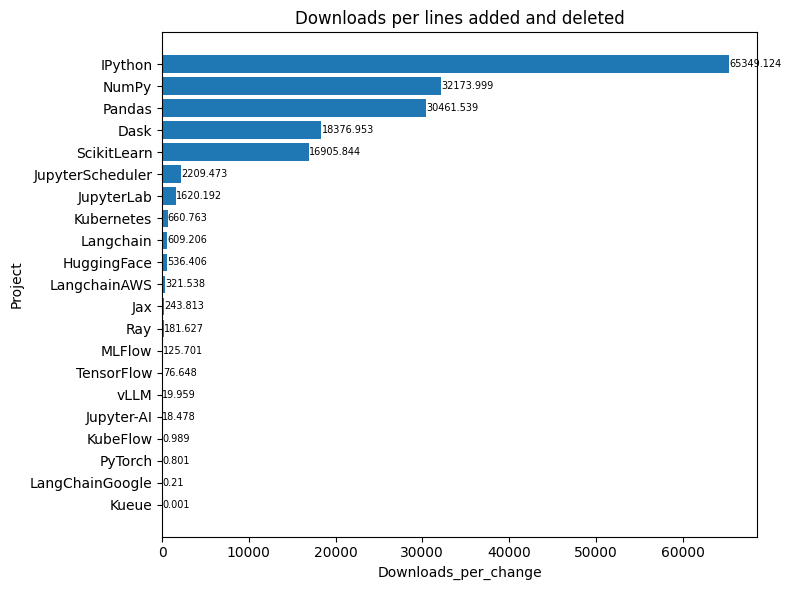

In [6]:
df = projects.copy()
# Sort the DataFrame by Values in descending order
df_sorted = df.sort_values(by='downloads_per_change', ascending=False)

# Create a horizontal bar plot
plt.figure(figsize=(8, 6))
plt.barh(df_sorted['name'], df_sorted['downloads_per_change'])
plt.xlabel('Downloads_per_change')
plt.ylabel('Project')
plt.title('Downloads per lines added and deleted')

# Add value labels to each bar
for index, value in enumerate(df_sorted['downloads_per_change'].round(3)):
    plt.text(value + 1, index, str(value), va='center', fontsize=7)

# Show the plot
plt.gca().invert_yaxis()  # Invert y-axis to display highest values at the top
plt.tight_layout()
plt.show()

In [7]:
projects[['downloads_per_change']] = projects[['downloads_per_change']].map(lambda x: f'{x:.2f}')
# Convert the DataFrame to LaTeX format
latex_code = projects.to_latex(index=False)
print(latex_code)

\begin{tabular}{lllrrl}
\toprule
name & repo & pypi_package_name & 6mo_downloads & 6mo_changes & downloads_per_change \\
\midrule
Dask &  dask/dask &  dask & 137036942 & 7457 & 18376.95 \\
HuggingFace &  huggingface/transformers &  transformers & 615182150 & 1146859 & 536.41 \\
IPython &  ipython/ipython &  ipython & 524949513 & 8033 & 65349.12 \\
Jax &  jax-ml/jax &  jax & 75853043 & 311112 & 243.81 \\
JupyterScheduler &  jupyter-server/jupyter-scheduler &  jupyter-scheduler & 121521 & 55 & 2209.47 \\
Jupyter-AI &  jupyterlab/jupyter-ai &  jupyter-ai & 897504 & 48572 & 18.48 \\
JupyterLab &  jupyterlab/jupyterlab &  jupyterlab & 254384699 & 157009 & 1620.19 \\
KubeFlow &  kubeflow/kubeflow &  kubeflow & 379218 & 383298 & 0.99 \\
Kubernetes &  kubernetes/kubernetes &  kubernetes & 519803832 & 786672 & 660.76 \\
Kueue &  kubernetes-sigs/kueue &  kueue & 753 & 677285 & 0.00 \\
LangchainAWS &  langchain-ai/langchain-aws &  langchain-aws & 38771056 & 120580 & 321.54 \\
Langchain &  langcha